![](https://in.pinterest.com/pin/142004194498044870/)

### loading all the library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset1 Batsman

In [2]:
df1=pd.read_csv('/kaggle/input/ipl-2025/ipl_batsman.csv')
df1.head()

,match_id,date,player_team,striker,batting_position,balls_faced,runs_scored,strike_rate,dots,singles,doubles,triples,fours,fives,sixes,dismissal_type
0,202501,2025-03-22,KKR,de Kock,1,5,4,80.000000,4,0,0,0,1,0,0,caught
1,202501,2025-03-22,KKR,Rahane,2,31,56,180.645161,14,6,1,0,6,0,4,caught
2,202501,2025-03-22,KKR,Narine,3,26,44,169.230769,13,4,1,0,5,0,3,caught
3,202501,2025-03-22,KKR,Venkatesh Iyer,4,7,6,85.714286,4,2,0,0,1,0,0,bowled
4,202501,2025-03-22,KKR,Angkrish Raghuvanshi,5,22,30,136.363636,4,14,1,0,2,0,1,caught


## EDA

In [3]:
df1.shape # to get shape of dataset

(1127, 16)

In [4]:
df1.info() # to get basic info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1127 entries, 0 to 1126
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   match_id          1127 non-null   int64  
 1   date              1127 non-null   object 
 2   player_team       1127 non-null   object 
 3   striker           1127 non-null   object 
 4   batting_position  1127 non-null   int64  
 5   balls_faced       1127 non-null   int64  
 6   runs_scored       1127 non-null   int64  
 7   strike_rate       1127 non-null   float64
 8   dots              1127 non-null   int64  
 9   singles           1127 non-null   int64  
 10  doubles           1127 non-null   int64  
 11  triples           1127 non-null   int64  
 12  fours             1127 non-null   int64  
 13  fives             1127 non-null   int64  
 14  sixes             1127 non-null   int64  
 15  dismissal_type    1127 non-null   object 
dtypes: float64(1), int64(11), object(4)
memory

In [5]:
df1.describe() # to get detailed info about the data

,match_id,batting_position,balls_faced,runs_scored,strike_rate,dots,singles,doubles,triples,fours,fives,sixes
count,1127.000000,1127.000000,1127.000000,1127.000000,1127.000000,1127.000000,1127.000000,1127.000000,1127.000000,1127.000000,1127.000000,1127.000000
mean,202536.704525,4.697427,14.656610,22.377107,131.978890,4.950311,5.669033,0.858917,0.024845,2.001775,0.001775,1.149956
std,21.646412,2.716279,12.727926,23.091769,78.074885,3.929125,5.907633,1.246155,0.161323,2.412224,0.042108,1.641399
min,202501.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,202518.000000,2.000000,5.000000,4.000000,83.333333,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,202536.000000,4.000000,11.000000,15.000000,133.333333,4.000000,4.000000,0.000000,0.000000,1.000000,0.000000,1.000000
75%,202555.000000,7.000000,21.500000,34.000000,178.319624,7.000000,8.000000,1.000000,0.000000,3.000000,0.000000,2.000000
max,202574.000000,11.000000,65.000000,141.000000,600.000000,21.000000,30.000000,8.000000,2.000000,14.000000,1.000000,11.000000


In [6]:
df1.isnull().sum() # to know which feature has null values

match_id            0
date                0
player_team         0
striker             0
batting_position    0
balls_faced         0
runs_scored         0
strike_rate         0
dots                0
singles             0
doubles             0
triples             0
fours               0
fives               0
sixes               0
dismissal_type      0
dtype: int64

it shows there are no null values in it

In [7]:
df1.duplicated().sum() # to know all the duplicated values

np.int64(0)

from which we can see there are no null values

In [8]:
df1.nunique()

match_id             74
date                 62
player_team          10
striker             168
batting_position     11
balls_faced          57
runs_scored         100
strike_rate         374
dots                 22
singles              31
doubles               9
triples               3
fours                14
fives                 2
sixes                12
dismissal_type        9
dtype: int64

## 1.Match Participation

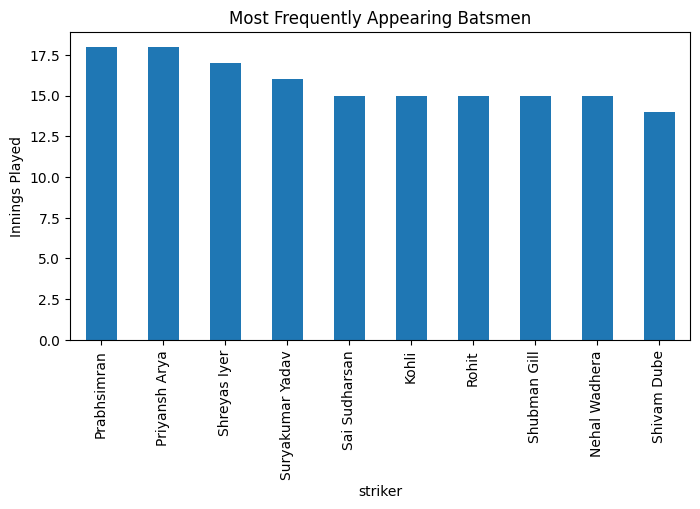

In [9]:
matches_per_player = df1["striker"].value_counts().head(10)

matches_per_player.plot(kind="bar", figsize=(8,4))
plt.title("Most Frequently Appearing Batsmen")
plt.ylabel("Innings Played")
plt.show()

- Players with higher appearances indicate consistent selection
and trust from team management.


## 2.Runs Scored Distribution

To understand how runs are spread across players and identify skewness.

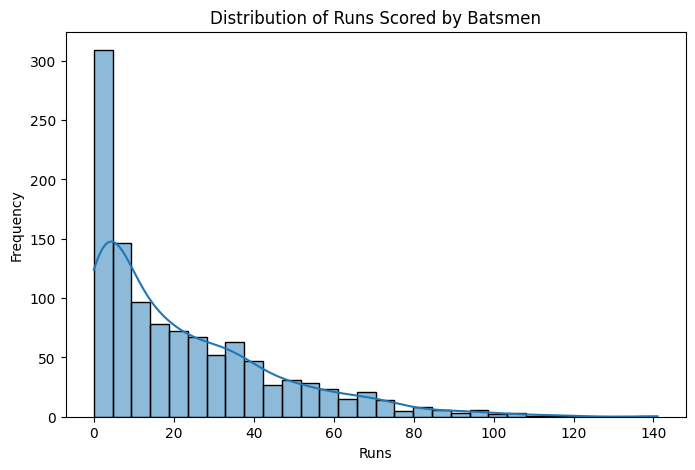

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df1["runs_scored"], bins=30, kde=True)
plt.title("Distribution of Runs Scored by Batsmen")
plt.xlabel("Runs")
plt.ylabel("Frequency")
plt.show()


- Most players score low to moderate runs

- A small number of players contribute very high runs

- Distribution is right-skewed, common in T20 cricket

## 3.strike rate analysis

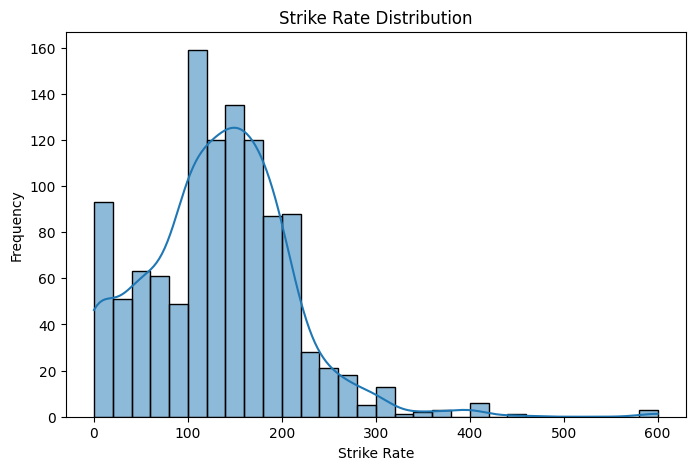

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df1["strike_rate"], bins=30, kde=True)
plt.title("Strike Rate Distribution")
plt.xlabel("Strike Rate")
plt.ylabel("Frequency")
plt.show()

- Majority of batsmen operate in the 120–160 strike rate range

- Few players play ultra-aggressive roles (>180 SR)

## 4.Runs vs Strike Rate Relationship

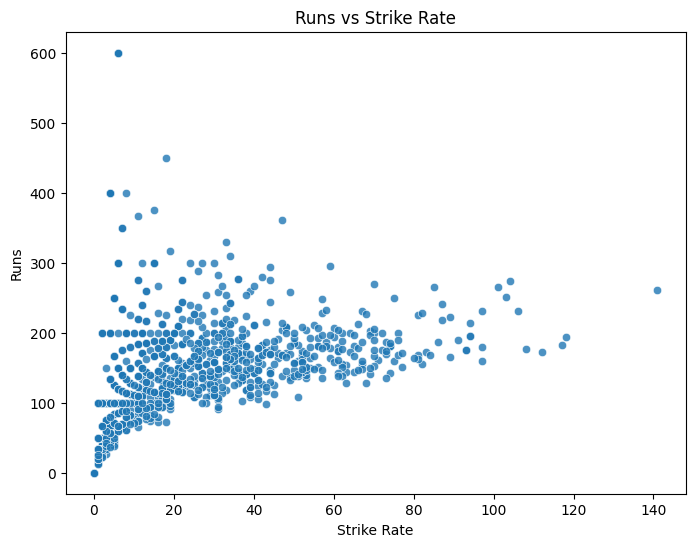

In [12]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='runs_scored',y='strike_rate',data=df1,alpha=0.8)
plt.title("Runs vs Strike Rate")
plt.xlabel("Strike Rate")
plt.ylabel("Runs")
plt.show()

- High strike rate does not always mean high runs

- Top performers combine volume + efficiency

- Useful for identifying impact players

## 5.Boundry hitters

In [13]:
# Create total boundaries
df1["Boundaries"] = df1["fours"] + df1["sixes"]

# Aggregate per player
player_boundaries = (
    df1
    .groupby("striker", as_index=False)["Boundaries"]
    .sum()
)

In [14]:
top10 = player_boundaries.sort_values(
    "Boundaries", ascending=False
).head(10)

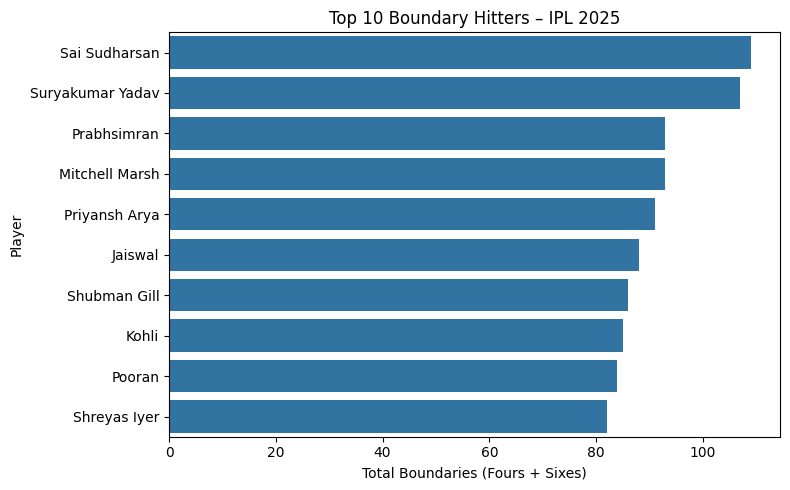

In [15]:
plt.figure(figsize=(8,5))

sns.barplot(data=top10, x="Boundaries", y="striker")

plt.title("Top 10 Boundary Hitters – IPL 2025")
plt.xlabel("Total Boundaries (Fours + Sixes)")
plt.ylabel("Player")

plt.tight_layout()
plt.show()


- To identify the most aggressive batsmen, we aggregated total boundaries 
(fours + sixes) scored by each player across the season. After grouping 
by player and summing boundary counts, the top 10 boundary hitters were 
visualized using a horizontal bar chart for better readability.

- This analysis highlights players who consistently contribute quick runs 
and play a key role in shifting match momentum in T20 cricket.

## 6.Balls Faced vs Runs

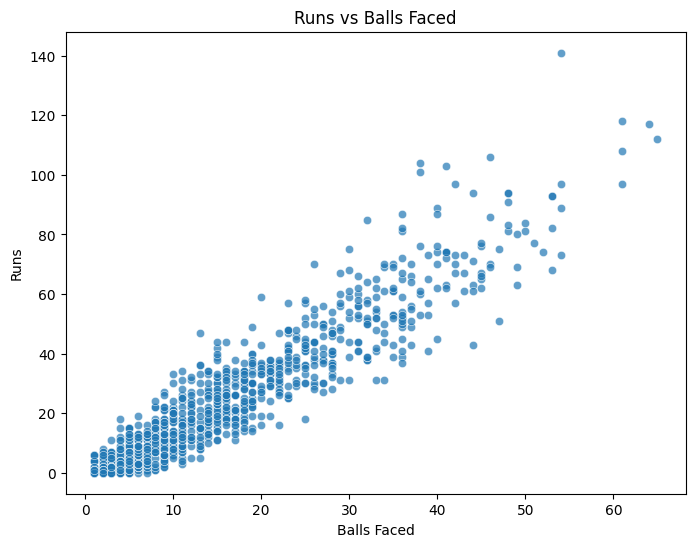

In [16]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df1,
    x="balls_faced",
    y="runs_scored",
    alpha=0.7
)
plt.title("Runs vs Balls Faced")
plt.xlabel("Balls Faced")
plt.ylabel("Runs")
plt.show()

- Linear relationship indicates consistency

- Outliers show high strike rate innings

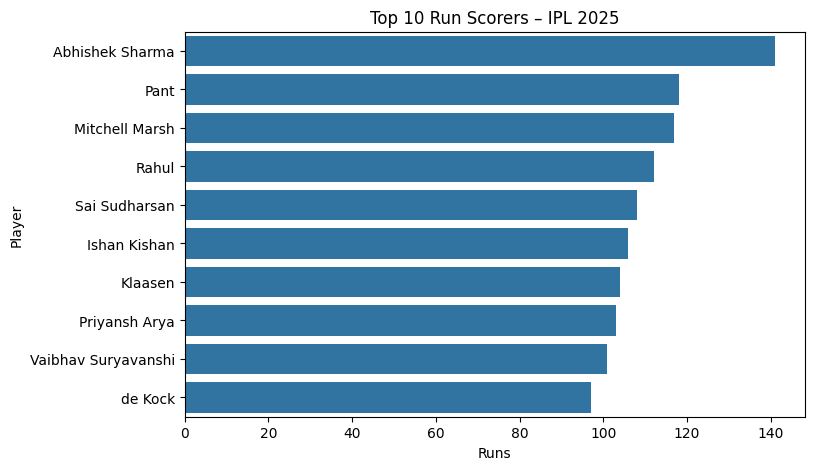

In [17]:
top_scorers = df1.sort_values("runs_scored", ascending=False).head(10)

plt.figure(figsize=(8,5))
sns.barplot(data=top_scorers, x="runs_scored", y="striker")
plt.title("Top 10 Run Scorers – IPL 2025")
plt.xlabel("Runs")
plt.ylabel("Player")
plt.show()

- this shows us the highest score scored by an individual player in a single inning
- also shows player who often plays anchor or consistent finisher roles

## 7.Batting Position Analysis

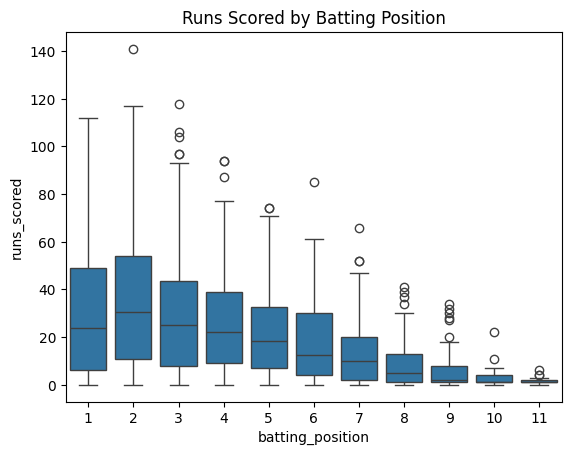

In [18]:
sns.boxplot(x="batting_position", y="runs_scored", data=df1)
plt.title("Runs Scored by Batting Position")
plt.show()

- Top-order batsmen generally score higher due to more balls faced.
- Middle and lower order players play specialized finishing roles.


## 8.Running Between the Wickets

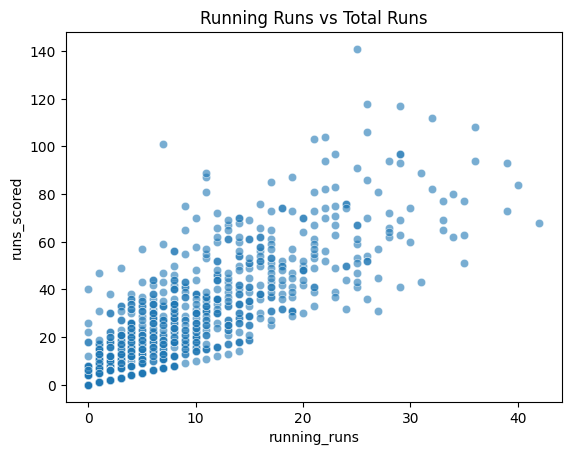

In [19]:
df1["running_runs"] = (
    df1["singles"]
    + 2*df1["doubles"]
    + 3*df1["triples"]
    + 5*df1["fives"]
)

sns.scatterplot(
    data=df1,
    x="running_runs",
    y="runs_scored",
    alpha=0.6
)
plt.title("Running Runs vs Total Runs")
plt.show()

- Running between the wickets plays a vital role for anchors and players on slower pitches.


## 9.Team-wise Batting Strength

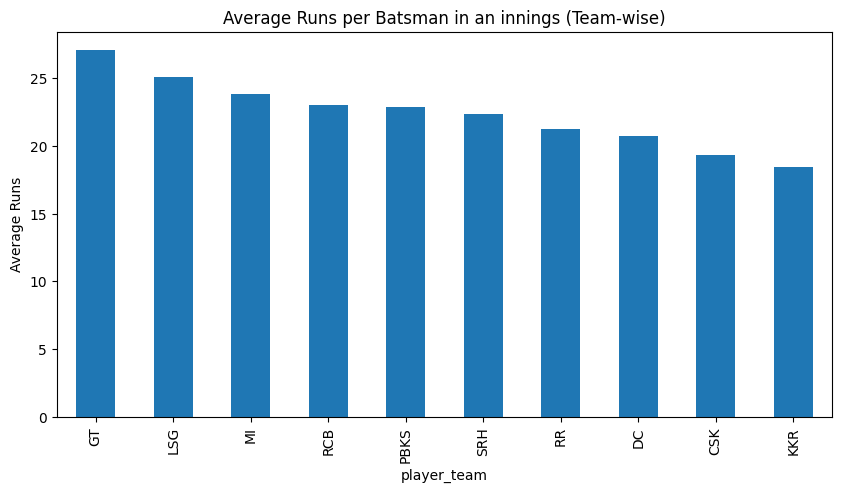

In [20]:
team_runs = df1.groupby("player_team")["runs_scored"].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
team_runs.plot(kind="bar")
plt.title("Average Runs per Batsman in an innings (Team-wise)")
plt.ylabel("Average Runs")
plt.show()

- Teams with higher averages show batting depth

- Useful indicator of team dominance

## 10.Dismissal Analysis

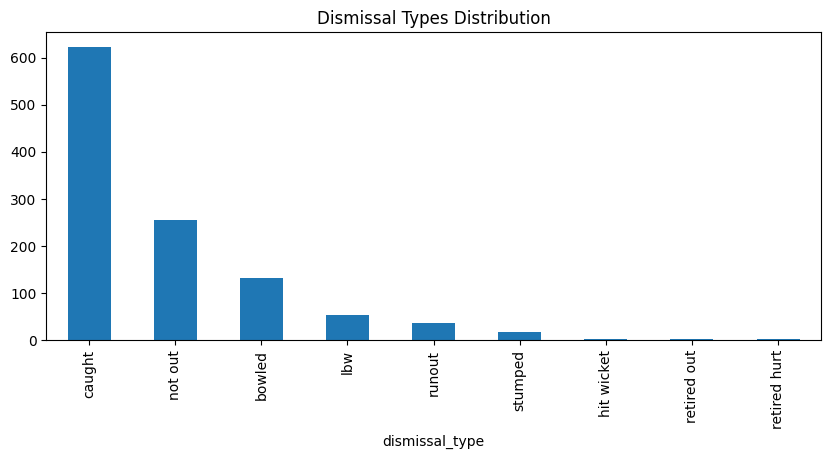

In [21]:
df1["dismissal_type"].value_counts().plot(kind="bar", figsize=(10,4))
plt.title("Dismissal Types Distribution")
plt.show()

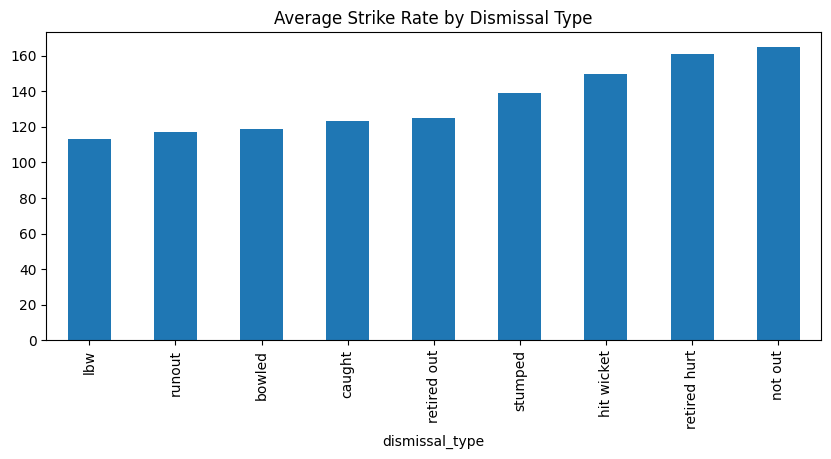

In [22]:
dismissal_sr = df1.groupby("dismissal_type")["strike_rate"].mean().sort_values()

dismissal_sr.plot(kind="bar", figsize=(10,4))
plt.title("Average Strike Rate by Dismissal Type")
plt.show()

- Certain dismissal types are associated with aggressive batting.
- This helps distinguish between attacking and defensive batting styles.


## 11.Correlation Between Batting Metrics

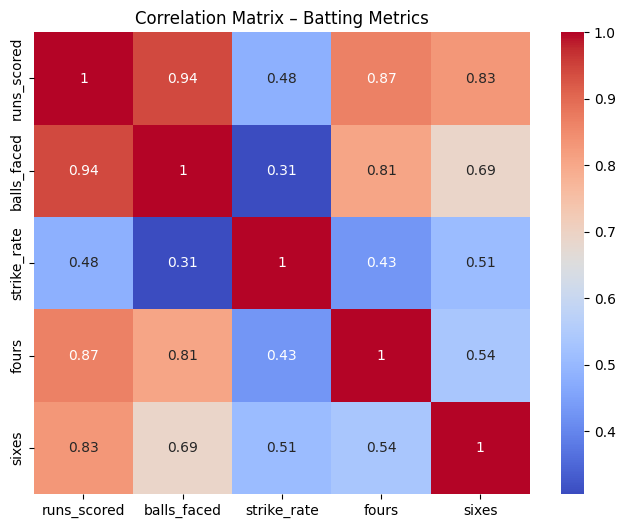

In [23]:
plt.figure(figsize=(8,6))
sns.heatmap(
    df1[["runs_scored", "balls_faced", "strike_rate", "fours", "sixes"]].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Matrix – Batting Metrics")
plt.show()

- Runs strongly correlate with balls faced

- Sixes show stronger impact on strike rate

- Useful for feature selection in ML models

## Key EDA Takeaways 

- Batting performance is highly skewed, with few elite contributors

- Strike rate alone does not define success; consistency matters

- Boundary hitters play a critical role in T20 dynamics

- Team-wise analysis highlights batting depth and balance

- These insights can support player ranking, match prediction, and team strategy models

# Dataset2 Bowlers

In [24]:
df2=pd.read_csv('/kaggle/input/ipl-2025/ipl_bowler.csv')
df2.head()

,match_id,innings,bowler,runs_conceded,wickets_taken,dots_bowled,fours_conceded,sixes_conceded,bowling_team,opposition_team,overs_bowled,economy_rate
0,202501,1,Hazlewood,23,2,15,3,1,RCB,KKR,4.0,5.75
1,202501,1,Krunal Pandya,29,3,8,2,1,RCB,KKR,4.0,7.25
2,202501,1,Livingstone,14,0,2,1,0,RCB,KKR,2.0,7.00
3,202501,1,Rasikh Salam,36,1,8,3,3,RCB,KKR,3.0,12.00
4,202501,1,Suyash Sharma,47,1,8,6,2,RCB,KKR,4.0,11.75


## EDA

In [25]:
df2.shape # to know dataset size

(870, 12)

In [26]:
df2.info() # to get basic info about the data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 870 entries, 0 to 869
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   match_id         870 non-null    int64  
 1   innings          870 non-null    int64  
 2   bowler           870 non-null    object 
 3   runs_conceded    870 non-null    int64  
 4   wickets_taken    870 non-null    int64  
 5   dots_bowled      870 non-null    int64  
 6   fours_conceded   870 non-null    int64  
 7   sixes_conceded   870 non-null    int64  
 8   bowling_team     870 non-null    object 
 9   opposition_team  870 non-null    object 
 10  overs_bowled     870 non-null    float64
 11  economy_rate     870 non-null    float64
dtypes: float64(2), int64(7), object(3)
memory usage: 81.7+ KB


In [27]:
df2.describe() # to get the detailed info about the data

,match_id,innings,runs_conceded,wickets_taken,dots_bowled,fours_conceded,sixes_conceded,overs_bowled,economy_rate
count,870.000000,870.000000,870.000000,870.000000,870.000000,870.000000,870.000000,870.000000,870.000000
mean,202537.278161,1.506897,30.451724,1.003448,6.137931,2.621839,1.489655,3.151034,9.996084
std,21.490349,0.509358,12.258131,1.043909,3.310451,1.753046,1.318806,1.028721,3.747506
min,202501.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.100000,2.000000
25%,202519.000000,1.000000,22.000000,0.000000,4.000000,1.000000,0.000000,2.300000,7.500000
50%,202537.000000,2.000000,30.000000,1.000000,6.000000,2.000000,1.000000,3.750000,9.666667
75%,202556.000000,2.000000,39.000000,2.000000,8.000000,4.000000,2.000000,4.000000,11.750000
max,202574.000000,4.000000,80.000000,6.000000,17.000000,10.000000,7.000000,4.100000,54.000000


In [28]:
df2.isnull().sum() # to check if theres any null values

match_id           0
innings            0
bowler             0
runs_conceded      0
wickets_taken      0
dots_bowled        0
fours_conceded     0
sixes_conceded     0
bowling_team       0
opposition_team    0
overs_bowled       0
economy_rate       0
dtype: int64

which means there are no null values so we dont have to remove any data from the dataset

In [29]:
df2.duplicated().sum() # to check if there are any duplicated values

np.int64(0)

which means there isnt any duplicated values

In [30]:
df2.nunique() # to checl the unoque values for each feature

match_id            74
innings              4
bowler             129
runs_conceded       63
wickets_taken        7
dots_bowled         18
fours_conceded      11
sixes_conceded       8
bowling_team        10
opposition_team     10
overs_bowled        23
economy_rate       142
dtype: int64

## 1.Wickets Distribution

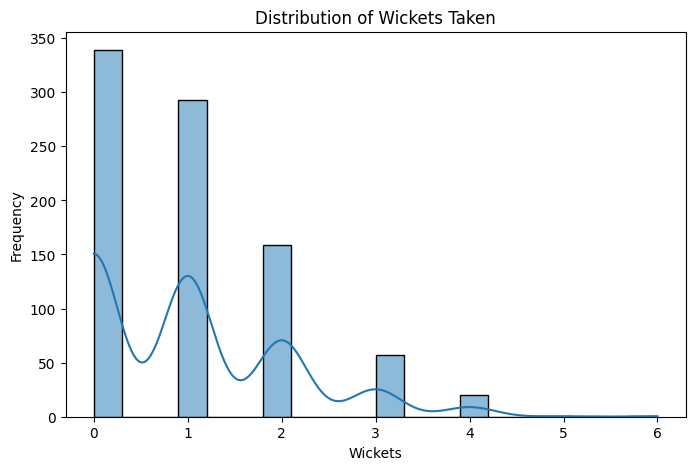

In [31]:
plt.figure(figsize=(8,5))
sns.histplot(df2["wickets_taken"], bins=20, kde=True)
plt.title("Distribution of Wickets Taken")
plt.xlabel("Wickets")
plt.ylabel("Frequency")
plt.show()

- Majority of bowlers take few wickets

- Only a small group are consistent strike bowlers

- Distribution is right-skewed

## 2.Economy rate analysis

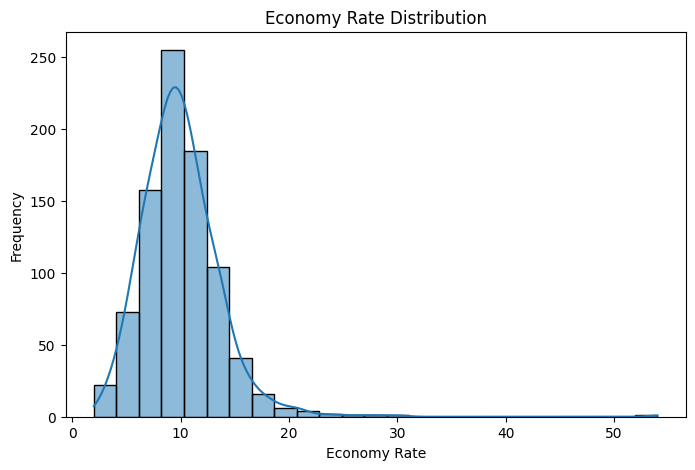

In [32]:
plt.figure(figsize=(8,5))
sns.histplot(df2["economy_rate"], bins=25, kde=True)
plt.title("Economy Rate Distribution")
plt.xlabel("Economy Rate")
plt.ylabel("Frequency")
plt.show()


- Most bowlers operate between 7–12 economy

- Extreme values often indicate death or powerplay specialists

## 3.Wickets economy tradeoff

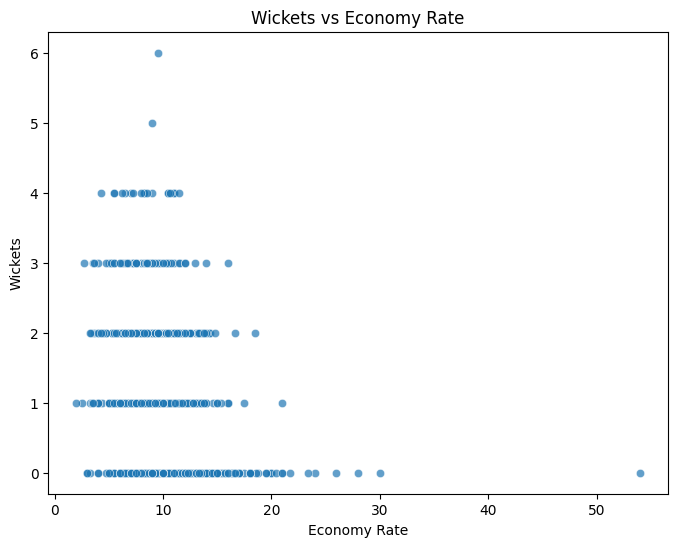

In [33]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df2,
    x="economy_rate",
    y="wickets_taken",
    alpha=0.7
)
plt.title("Wickets vs Economy Rate")
plt.xlabel("Economy Rate")
plt.ylabel("Wickets")
plt.show()

- Some bowlers sacrifice economy to take wickets

- Ideal bowlers appear in low economy + high wicket zone

## 4.Innings Analysis (1st vs 2nd innings)

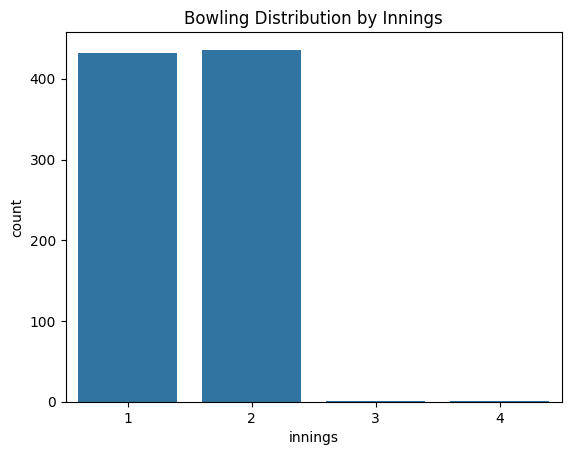

,wickets_taken,economy_rate
innings,,
1,1.092593,9.832525
2,0.915138,10.128997
3,2.000000,13.200000
4,0.000000,19.500000


In [34]:
sns.countplot(x="innings", data=df2)
plt.title("Bowling Distribution by Innings")
plt.show()
df2.groupby("innings")[["wickets_taken","economy_rate"]].mean()

- Bowling performance differs across innings.
- Second innings often show higher economy rates due to pressure of chasing targets.
- Third and Fourth innings means superover innings here

## 5.Bowler Participation Frequency

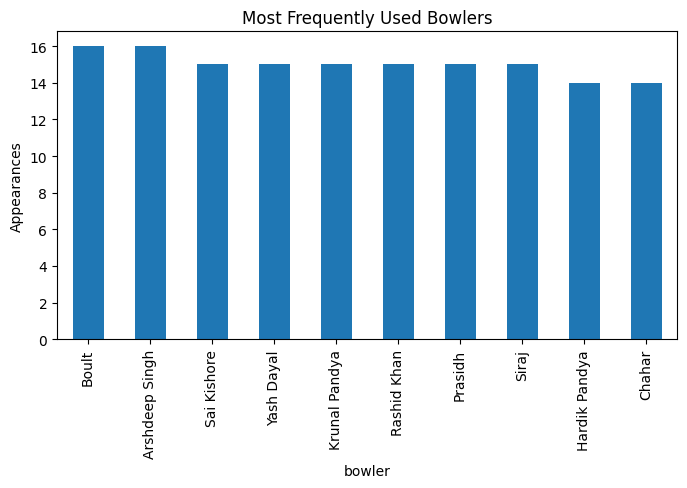

In [35]:
top_bowlers = df2["bowler"].value_counts().head(10)

top_bowlers.plot(kind="bar", figsize=(8,4))
plt.title("Most Frequently Used Bowlers")
plt.ylabel("Appearances")
plt.show()

- Frequently appearing bowlers indicate high trust and consistent selection by teams.
- These bowlers often form the core bowling attack.


## 6.Runs conceded distribution

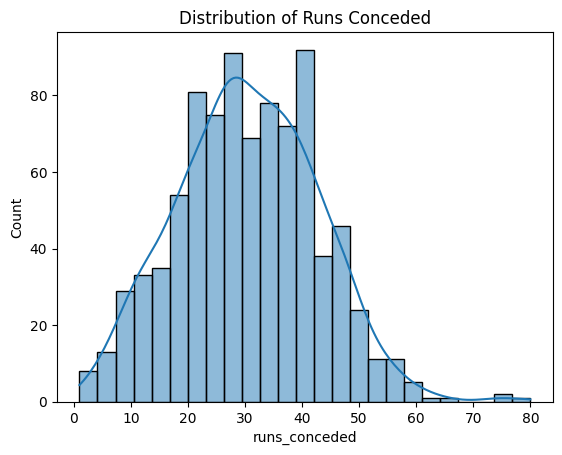

In [36]:
sns.histplot(df2["runs_conceded"], bins=25, kde=True)
plt.title("Distribution of Runs Conceded")
plt.show()

Dot balls vs wicket taken

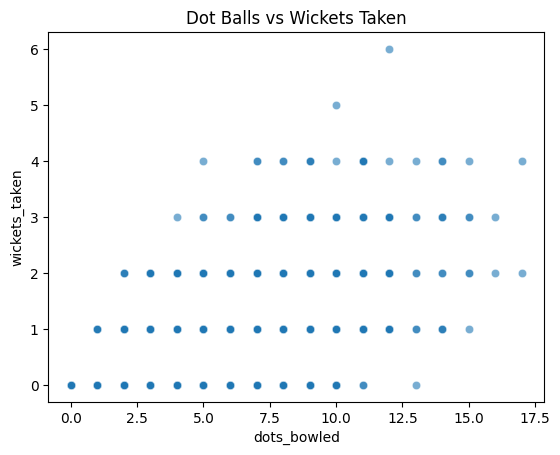

In [37]:
sns.scatterplot(
    data=df2,
    x="dots_bowled",
    y="wickets_taken",
    alpha=0.6
)
plt.title("Dot Balls vs Wickets Taken")
plt.show()

- Dot balls play a crucial role in building pressure.
- Higher dot-ball counts often lead to wicket-taking opportunities.


## 7.Overs bowled vs wicket

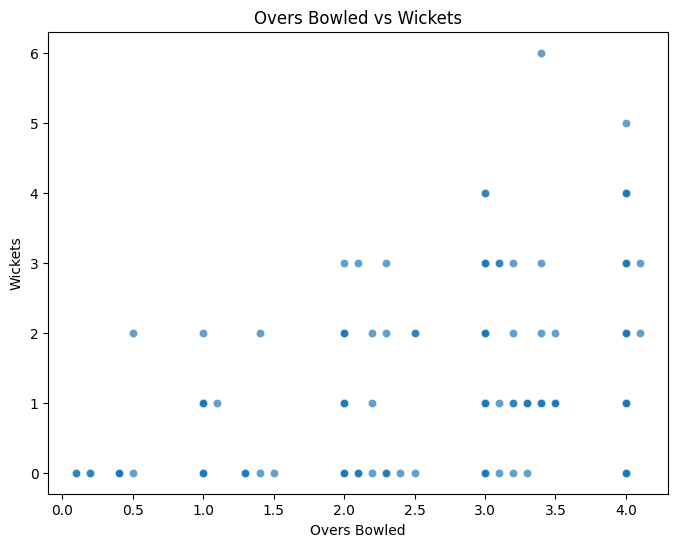

In [38]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df2,
    x="overs_bowled",
    y="wickets_taken",
    alpha=0.7
)
plt.title("Overs Bowled vs Wickets")
plt.xlabel("Overs Bowled")
plt.ylabel("Wickets")
plt.show()

- More overs usually mean more wickets

- Outliers indicate high-impact bowlers with fewer overs

## 8.Top wicket takers

In [39]:
player_wickets = (
    df2
    .groupby("bowler", as_index=False)["wickets_taken"]
    .sum()
)
top_wicket_takers = player_wickets.sort_values(
    "wickets_taken", ascending=False
).head(10)

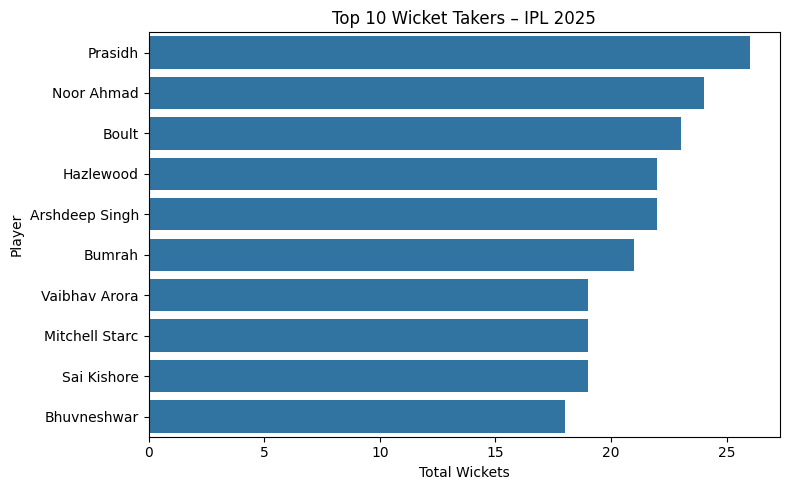

In [40]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=top_wicket_takers,
    x="wickets_taken",
    y="bowler"
)

plt.title("Top 10 Wicket Takers – IPL 2025")
plt.xlabel("Total Wickets")
plt.ylabel("Player")
plt.tight_layout()
plt.show()

- These bowlers are the primary strike options

- Often bowl in powerplay or death overs

## 9.Bowling Team vs Opposition Team

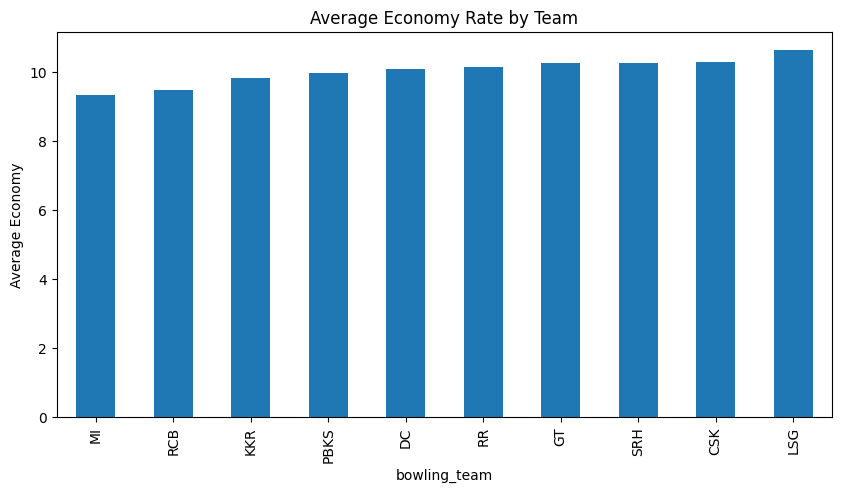

In [41]:
team_economy = df2.groupby("bowling_team")["economy_rate"].mean().sort_values()

plt.figure(figsize=(10,5))
team_economy.plot(kind="bar")
plt.title("Average Economy Rate by Team")
plt.ylabel("Average Economy")
plt.show()

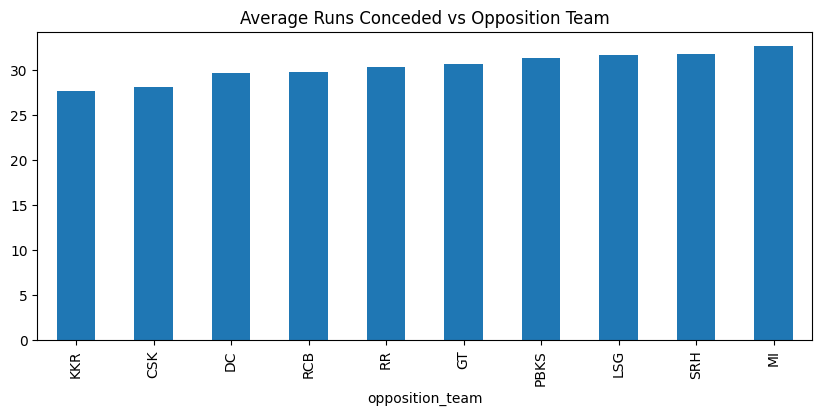

In [42]:
opp_runs = df2.groupby("opposition_team")["runs_conceded"].mean().sort_values()

opp_runs.plot(kind="bar", figsize=(10,4))
plt.title("Average Runs Conceded vs Opposition Team")
plt.show()

- Certain teams consistently bowl more economically.
- Some opposition teams are more aggressive, leading to higher runs conceded.


## 10.Correlation between bowling metrices

In [43]:
df2.columns

Index(['match_id', 'innings', 'bowler', 'runs_conceded', 'wickets_taken',
       'dots_bowled', 'fours_conceded', 'sixes_conceded', 'bowling_team',
       'opposition_team', 'overs_bowled', 'economy_rate'],
      dtype='object')

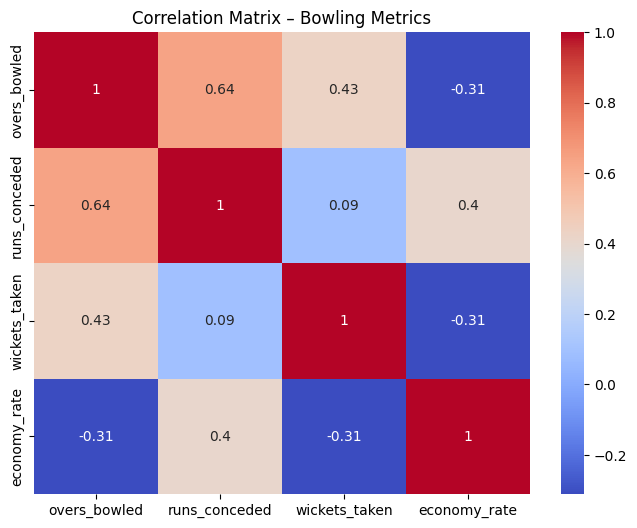

In [44]:
plt.figure(figsize=(8,6))
sns.heatmap(
    df2[["overs_bowled", "runs_conceded","wickets_taken", "economy_rate"]].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Matrix – Bowling Metrics")
plt.show()

- Economy strongly correlates with runs conceded

- Wickets have moderate relation with overs bowled

### Overall Bowling Insights

- Bowling performance varies significantly by innings and match context
- Dot balls are a key indicator of pressure-building bowling
- Boundary concession directly drives economy rate inflation
- Teams differ in bowling discipline and control
- These features are highly suitable for match outcome prediction and player evaluation models

# Dataset3 matches

In [45]:
df3=pd.read_csv('/kaggle/input/ipl-2025/matches.csv')
df3.head()

,date,venue,team1,team2,stage,match_winner,player_of_the_match,margin
0,"March 22,2025","Eden Gardens, Kolkata",KKR,RCB,League,RCB,Krunal Pandya,7 wickets
1,"March 23,2025","Rajiv Gandhi International Stadium, Hyderabad",SRH,RR,League,SRH,Ishan Kishan,44 runs
2,"March 23,2025","MA Chidambaram Stadium, Chennai",CSK,MI,League,CSK,Noor Ahmad,4 wickets
3,"March 24,2025","ACA-VDCA Cricket Stadium, Vishakhapatnam",DC,LSG,League,DC,Ashutosh Sharma,1 wicket
4,"March 25,2025","Narendra Modi Stadium, Ahmedabad",GT,PBKS,League,PBKS,Shreyas Iyer,11 runs


## EDA

In [46]:
df3.shape # to know the size of the dataset

(74, 8)

In [47]:
df3.info() # to know the basic info about the data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   date                 74 non-null     object
 1   venue                74 non-null     object
 2   team1                74 non-null     object
 3   team2                74 non-null     object
 4   stage                74 non-null     object
 5   match_winner         71 non-null     object
 6   player_of_the_match  71 non-null     object
 7   margin               70 non-null     object
dtypes: object(8)
memory usage: 4.8+ KB


In [48]:
df3.describe() # to get the detailed info about the data

,date,venue,team1,team2,stage,match_winner,player_of_the_match,margin
count,74,74,74,74,74,71,71,70
unique,62,13,10,10,3,10,53,37
top,"March 23,2025","Narendra Modi Stadium, Ahmedabad",PBKS,MI,League,PBKS,Krunal Pandya,8 wickets
freq,2,9,9,9,70,11,3,9


In [49]:
df3.isnull().sum() # to check if theres any null values

date                   0
venue                  0
team1                  0
team2                  0
stage                  0
match_winner           3
player_of_the_match    3
margin                 4
dtype: int64

which means there are some null values in our dataset lets remove them

In [50]:
df3.dropna(inplace=True) # to remove all the data which has null values

In [51]:
df3.isnull().sum(),df3.shape

(date                   0
 venue                  0
 team1                  0
 team2                  0
 stage                  0
 match_winner           0
 player_of_the_match    0
 margin                 0
 dtype: int64,
 (70, 8))

## 1.Date analysis

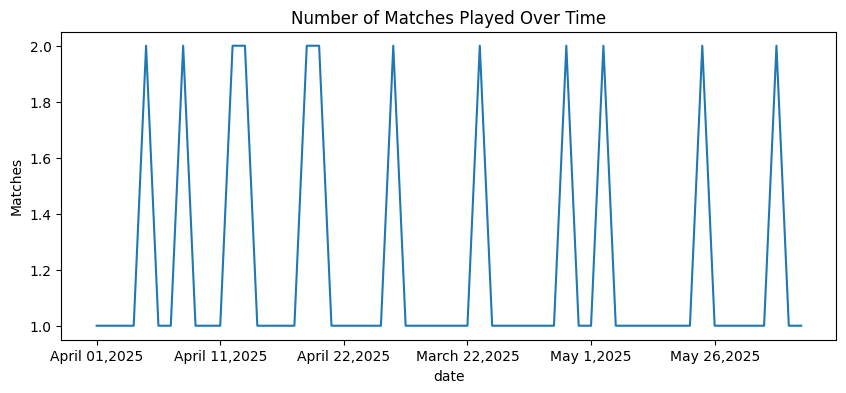

In [52]:
matches_per_day = df3.groupby("date").size()

matches_per_day.plot(figsize=(10,4))
plt.title("Number of Matches Played Over Time")
plt.ylabel("Matches")
plt.show()

- Matches are evenly distributed across the season.
- Scheduling density reflects league-stage clustering.


## 2.Venue Analysis

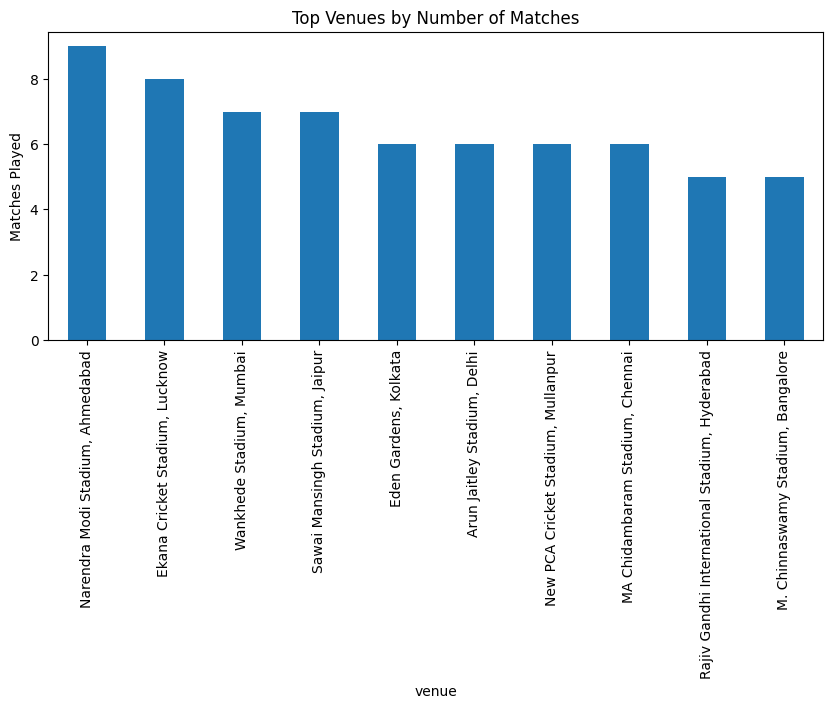

In [53]:
venue_matches = df3["venue"].value_counts()

venue_matches.head(10).plot(kind="bar", figsize=(10,4))
plt.title("Top Venues by Number of Matches")
plt.ylabel("Matches Played")
plt.show()

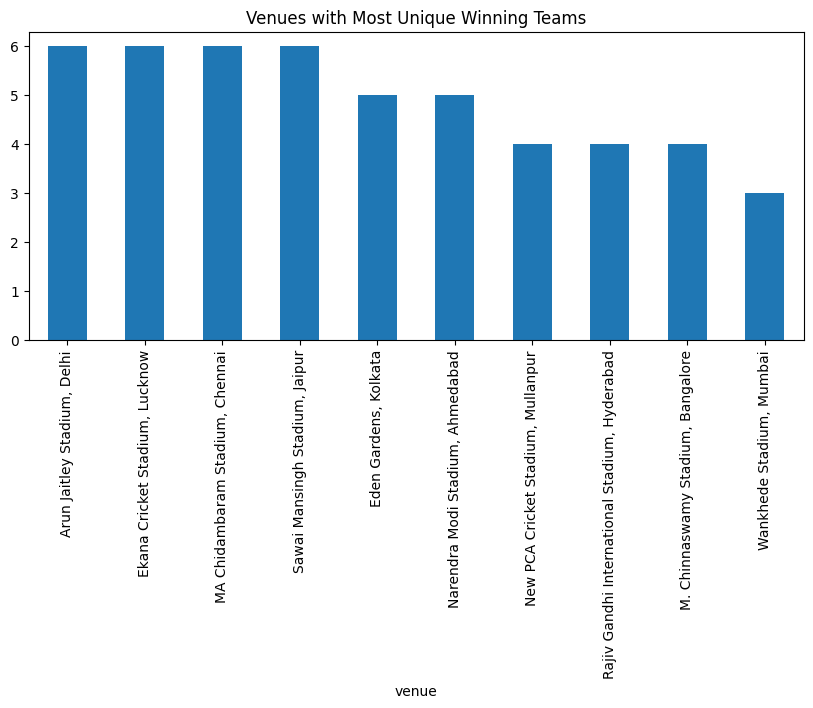

In [54]:
venue_wins = df3.groupby("venue")["match_winner"].nunique().sort_values(ascending=False)

venue_wins.head(10).plot(kind="bar", figsize=(10,4))
plt.title("Venues with Most Unique Winning Teams")
plt.show()

- Some venues host significantly more matches than others.
- Venues with diverse winners indicate neutral pitch conditions.


## 3.Team Participation

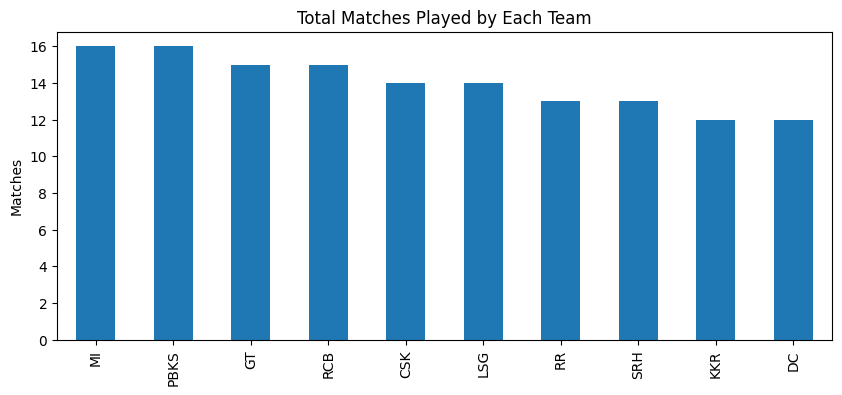

In [55]:
teams = pd.concat([df3["team1"], df3["team2"]])

teams.value_counts().plot(kind="bar", figsize=(10,4))
plt.title("Total Matches Played by Each Team")
plt.ylabel("Matches")
plt.show()

- Each team appears almost equally across the schedule,
ensuring fairness in league participation.


## 4.Match Stage Analysis

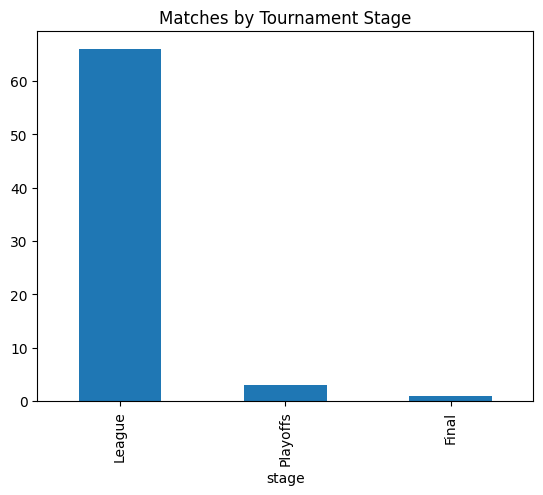

In [56]:
df3["stage"].value_counts().plot(kind="bar")
plt.title("Matches by Tournament Stage")
plt.show()

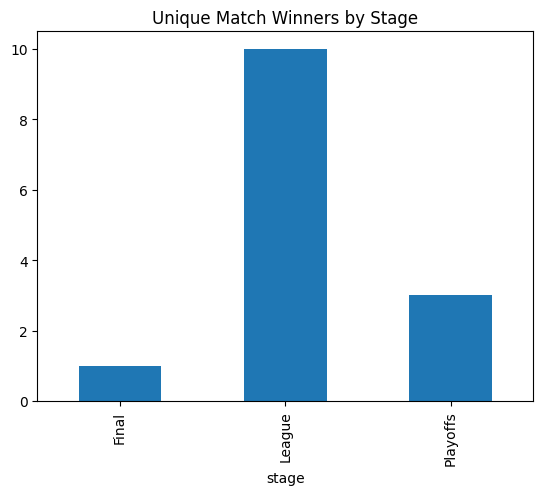

In [57]:
stage_winners = df3.groupby("stage")["match_winner"].nunique()

stage_winners.plot(kind="bar")
plt.title("Unique Match Winners by Stage")
plt.show()

- League-stage matches dominate the dataset.
- Knockout stages show reduced team diversity and higher pressure.


## 5.Match Winner Analysis

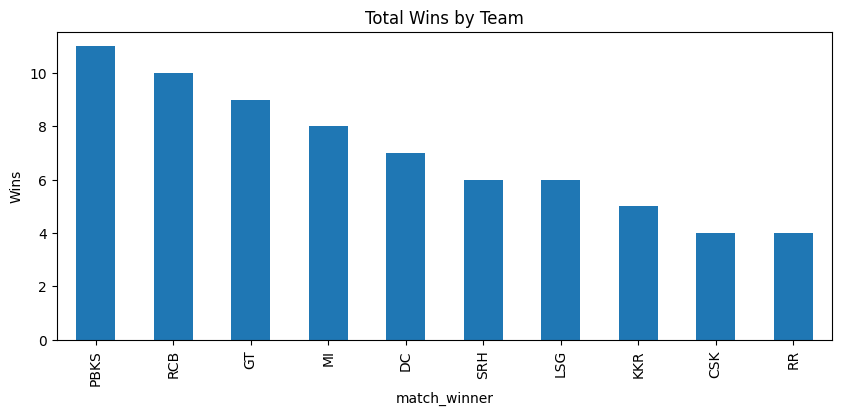

In [58]:
df3["match_winner"].value_counts().plot(kind="bar", figsize=(10,4))
plt.title("Total Wins by Team")
plt.ylabel("Wins")
plt.show()

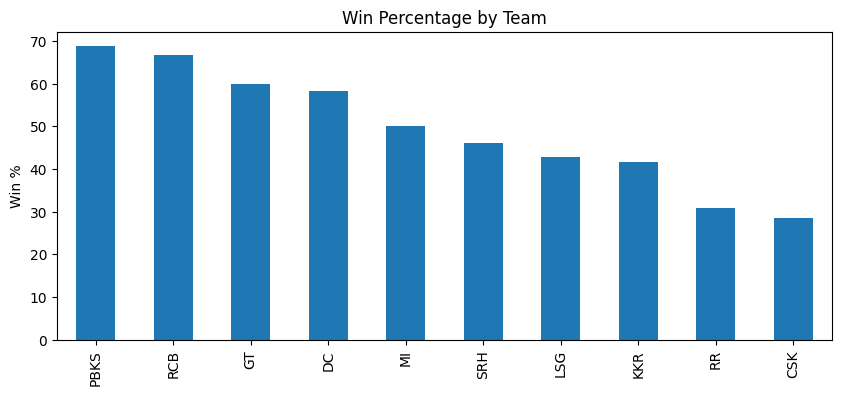

In [59]:
win_percentage = (
    df3["match_winner"].value_counts() /
    teams.value_counts()
) * 100

win_percentage.sort_values(ascending=False).plot(kind="bar", figsize=(10,4))
plt.title("Win Percentage by Team")
plt.ylabel("Win %")
plt.show()

- Win counts and win percentages highlight dominant teams.
- Win percentage provides better insight than raw wins alone.


## 6.Player of the Match

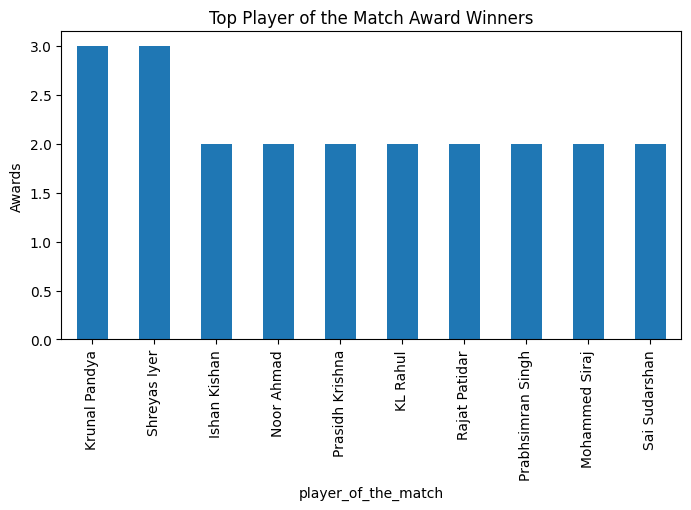

In [60]:
df3["player_of_the_match"].value_counts().head(10).plot(kind="bar", figsize=(8,4))
plt.title("Top Player of the Match Award Winners")
plt.ylabel("Awards")
plt.show()

- Repeated Player of the Match awards indicate consistent impact.
- Winning teams often feature standout individual performances.


## 7.Result Margin Analysis

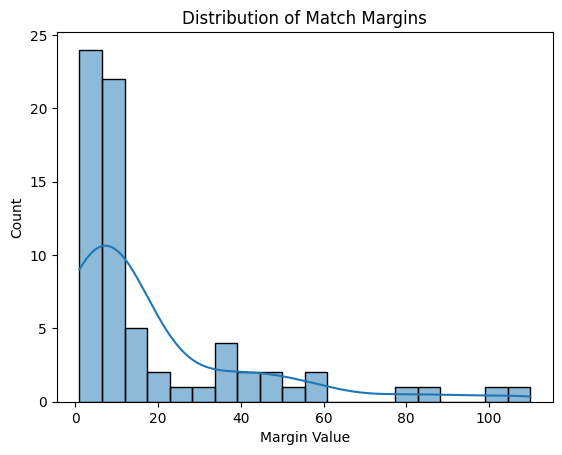

In [61]:
df3["margin_value"] = df3["margin"].str.extract(r"(\d+)").astype(int)
df3["margin_type"] = df3["margin"].str.extract("(runs|wickets)")

sns.histplot(df3["margin_value"], bins=20,kde=True)
plt.title("Distribution of Match Margins")
plt.xlabel("Margin Value")
plt.show()

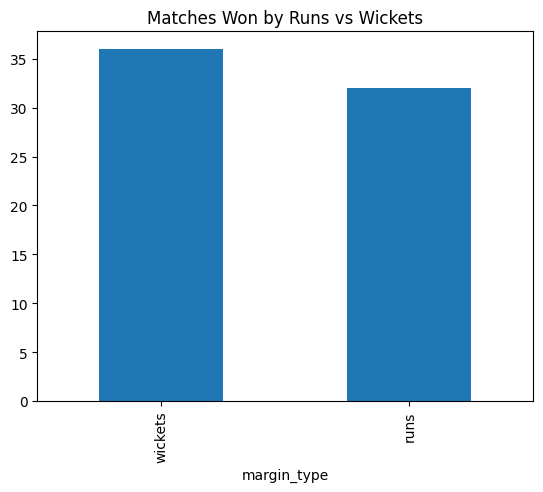

In [62]:
df3["margin_type"].value_counts().plot(kind="bar")
plt.title("Matches Won by Runs vs Wickets")
plt.show()

- Most matches are decided by small margins,
- highlighting the competitive nature of IPL.
- Run-based wins usually indicate defending success,
while wicket-based wins reflect chasing dominance.


## 8.Team1 vs Team2 Advantage

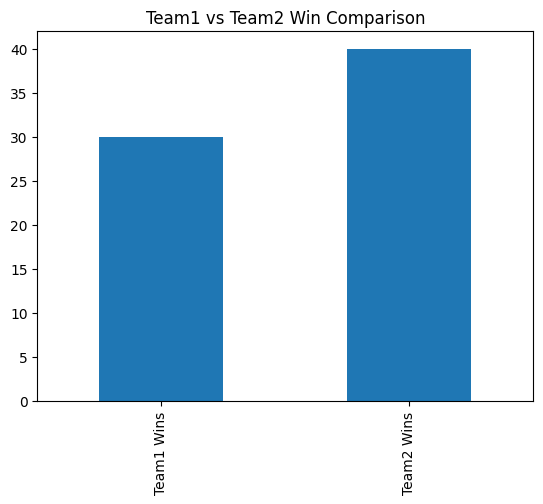

In [63]:
team1_wins = df3[df3["match_winner"] == df3["team1"]].shape[0]
team2_wins = df3[df3["match_winner"] == df3["team2"]].shape[0]

pd.Series(
    {"Team1 Wins": team1_wins, "Team2 Wins": team2_wins}
).plot(kind="bar")
plt.title("Team1 vs Team2 Win Comparison")
plt.show()

- No strong bias exists between Team1 and Team2 positions,
indicating fair scheduling and neutral toss impact.


## 9.Venue × Result Margin Interaction

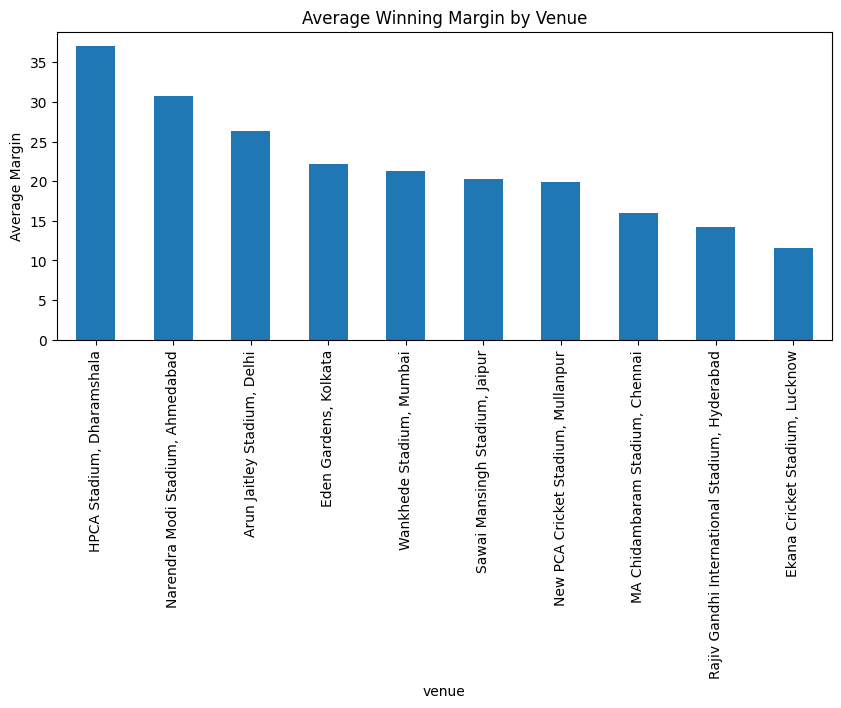

In [64]:
venue_margin = df3.groupby("venue")["margin_value"].mean().sort_values(ascending=False)

venue_margin.head(10).plot(kind="bar", figsize=(10,4))
plt.title("Average Winning Margin by Venue")
plt.ylabel("Average Margin")
plt.show()

- Some venues consistently produce high-margin results,
suggesting pitch or boundary-size influence.

### Overall Match-Level Insights

- Match outcomes are evenly distributed across teams and venues
- Most matches are closely contested with small winning margins
- Venue conditions influence match dominance
- Player of the Match awards align strongly with winning teams
- These features are critical for match outcome modeling and venue-based strategy analysis


If this notebook helped you in any way, an upvote would mean a lot and really motivate me to share more cricket and football analytics content.
Feedback and suggestions are always welcome!